# I'll be breaking the code into blocks by assignment
What I had to do for this first assignment was get the artists in a given week, find out the genre for each artist, and then apply those findings to the overall weekly listening to find the share of total listens that each genre had during a given week. The hard part was finding a variable to quantify in this API, however the genre share is a way to see the overall trend that occurs in a given genre and not just how much this individual listens to a given artist. 

In [6]:
import requests
import pandas as pd
import numpy as np

url = "http://ws.audioscrobbler.com/2.0/" #Url base for the API, used in my future F strings as inputs, F strings are awesome
YOUR_API_KEY = 'Your Last.fm API Goes here' #my API key, insert your key and the code will work as I used numerous f'strings for my requests (see How to reproduce for steps to obtain key)
artist='Cher'
#_________________________________________________________________________________________________________________________________________
#BLOCK 1.1 - Prime Data, find how many weeks and how to grab tags
#This below block gives me both the tag grabber for each of the artists I'm looking at as well as the weeks I'm counting. This is important
#because I'm looking to do a for loop in a for loop, essentially the main loop is going to cycle weeks and grab the listening data for that 
#week, the second loop is going to cycle between either the top 250 artists or the length of the amount of artists, whichever is smaller
#in order to get the weeks I need 'charts', in order to get the top tag and classify each artist I need 'toptagget', cher is my placeholder
toptagsreq=requests.get(f'{url}?method=artist.gettoptags&artist={artist}&api_key={YOUR_API_KEY}&format=json')
# gets the top tag for an artist specified in the F STRING {ARTIST} blob, if i change the artist in the line at the beginning it will change from cher
toptagget=toptagsreq.json() 
#returns our JSON for the request of the artist tags, I removed the print from this final submission, but it is in assignment 1
chartrequest=requests.get(f'{url}?method=tag.getweeklychartlist&tag=rock&api_key={YOUR_API_KEY}&format=json') 
charts=chartrequest.json()
#toptagget gets changed in the loop that gets the tags, I'm just calling it here so I can reference it at a later point down the line.

#_________________________________________________________________________________________________________________________________________
#BLOCK 1.2 - Get Artists for Weeks
#This entire loop essentially looks at each week of listening data that we have, and within that week, pulls all the artists up to 250
# and puts them into a master list, for every week. This master list 100% has duplicates but I erase them at a later point (BLOCK 3)
#listylist prints my list, I know you said you didnt want prints so I just turned it into a comment and moved it up here

chartnum=0 
# Begins my counter for the loop to see what week we are in
listylist=[] 
#creates an empty list for the artists to go in later
for i in charts['weeklychartlist']['chart']: 
    #Begins putting us through the large loop of getting weekly data
    fromloop = charts['weeklychartlist']['chart'][chartnum]['from'] 
    #sets beginning of date search
    toloop = charts['weeklychartlist']['chart'][chartnum]['to'] 
    #sets end of date search
    weeklisteningdata = requests.get(f'{url}?method=user.getweeklyartistchart&user=rj&api_key={YOUR_API_KEY}&format=json&to={toloop}&from={fromloop}') 
    #gets my data for the URL that I'm looking at 
    rjdata=weeklisteningdata.json() 
    #this gets the json data that I can parse through and find the lists of artists for every week
    for j in range(0, min(250, len(rjdata['weeklyartistchart']['artist']))): 
        #sets my criteria that for a range between 0 and either 250 or the length of the data (whichever is lower), append the artist to the lsit
        listylist.append(rjdata['weeklyartistchart']['artist'][j]['name']) 
        #Puts all of the artists into the master list, titled 'listylist'
        print(rjdata['weeklyartistchart']['artist'][j]['name'],chartnum) #this line isn't necessary, just lets me see the artists I'm dealing with and how many
    chartnum+=1 #advances the chart number counter 1 item, moves onto the next week 
#Breaking here so if you run and something explodes you can stop the kernel at this block.

Aerosmith 0
Metallica 0
Miles Davis 0
Guns N' Roses 0
Dream Theater 0
R.E.M. 0
Radiohead 0
Moby 0
Joe Satriani 0
Led Zeppelin 0
Counting Crows 0
Free 0
Red Hot Chili Peppers 0
Jimi Hendrix 0
Badly Drawn Boy 0
The Rolling Stones 0
Portishead 0
Matchbox Twenty 0
Jamiroquai 0
The Beatles 0
Goo Goo Dolls 0
Ben Folds Five 0
Dido 0
Eels 0
Stevie Wonder 0
The Jimi Hendrix Experience 0
David Bowie 0
Dire Straits 0
Rage Against the Machine 0
A Perfect Circle 0
Dan Reed Network 0
Beck 0
Nine Inch Nails 0
Ben Harper 0
Fun Lovin' Criminals 0
Barenaked Ladies 0
Jeff Buckley 0
Norah Jones 0
Buckcherry 0
Foo Fighters 0
King's X 0
The Doors 0
The Police 0
Queen 0
(hed) Planet Earth 0
The Cure 0
U2 0
Bruce Springsteen 0
Nirvana 0
The Smashing Pumpkins 0
Pink Floyd 0
Coldplay 0
Herbie Hancock 0
The Classic Chill Out Album 0
Air 0
Lenny Kravitz 0
The Velvet Underground 0
Beth Orton 0
Judas Priest 0
Tom Waits 0
Deep Purple 0
Desert Sessions 0
Pearl Jam 0
Weezer 0
Rammstein 0
Neil Young 0
Def Leppard 0
Fug

In [7]:
#BLOCK 1.3 - Find + Track Genres
#Time was a product of Claude, my code kept on stopping due to too many requests, so I asked how I could get around my API's limit and
#using a sleep was the suggestion and it thankfully worked
import urllib.parse as up
import time

#here I make a dictionary so that if an artist is already in the dictionary it skips the loop and passes onto the next artist.
#for the new artists, it looks up the top tag and puts it as the value in the dictionary with the name of the artist as the key
#sickdict #shows me the dictionary at the end of everything, again i disabled it and put it up here so you know its there but doesn't
#run and doesnt look bad.

sickdict={} 
#makes the empty dictionary for my artists to hide out in 
counter=0 
# starts the counter at 0
for item in listylist: 
#goes through each of the items(artists) in my listylist (Master list of every artist listened to)
    itemencode = up.quote(item) 
    #pencode encodes the name to combat the problem discussed above. (encoding strange characters)
    if item not in sickdict: 
        #checking to see if the artist we found is in the dictionary above, if yes skip to the else condition
        toptagsreq=requests.get(f'{url}?method=artist.gettoptags&artist={itemencode}&api_key={YOUR_API_KEY}&format=json')
        # gets the top tag for an artist specified in the F STRING {itemencode} blob
        toptagget=toptagsreq.json() 
        #here both toptagget and toptagsreq get reassigned from before (This is what I meant before)
        tags = toptagget['toptags']['tag'] 
        #gets all of the tags for a given artist {itemencode} blob above
        tag = tags[0]['name'] if len(tags) > 0 else 'unknown' 
        # returns the top tag for the artist, returns unknown if no tags exist
        sickdict[item]= tag 
        # puts item in the dictionary as a key, with the tag variable as the value
        print(item,tag,counter) # Print statement again, just disabling this line so that you know it's there but it doesnt run
    else: 
        pass
    #these lines make it so that i'm just moving on in the case that item is already in the dictionary, doesnt waste time
    counter+=1 
    #advances the counter by 1 to move onto the next artist.
    time.sleep(0.3) 
    #AI SUGGESTION, this is just so that the API doesn't take too many requests and give me a JSONDecodeError,


Aerosmith hard rock 0
Metallica metallica 1
Miles Davis jazz 2
Guns N' Roses hard rock 3
Dream Theater Progressive metal 4
R.E.M. rock 5
Radiohead rock 6
Moby electronic 7
Joe Satriani guitar virtuoso 8
Led Zeppelin classic rock 9
Counting Crows rock 10
Free classic rock 11
Red Hot Chili Peppers rock 12
Jimi Hendrix classic rock 13
Badly Drawn Boy indie 14
The Rolling Stones classic rock 15
Portishead trip-hop 16
Matchbox Twenty rock 17
Jamiroquai funk 18
The Beatles classic rock 19
Goo Goo Dolls rock 20
Ben Folds Five piano rock 21
Dido pop 22
Eels indie 23
Stevie Wonder soul 24
The Jimi Hendrix Experience Psychedelic Rock 25
David Bowie glam rock 26
Dire Straits classic rock 27
Rage Against the Machine alternative rock 28
A Perfect Circle alternative rock 29
Dan Reed Network rock 30
Beck alternative 31
Nine Inch Nails industrial 32
Ben Harper singer-songwriter 33
Fun Lovin' Criminals funk 34
Barenaked Ladies rock 35
Jeff Buckley singer-songwriter 36
Norah Jones jazz 37
Buckcherry har

KeyboardInterrupt: 

In [20]:
#_________________________________________________________________________________________________________________________________________
#BLOCK 1.4 - Classify Genres
#As per the Code you gave me, instead of running a loop, i used np.where statements after converting my sick dictionary to a dataframe
#and used pandas to change all of the tags 
sickdf=pd.DataFrame(list(sickdict.items()),columns=['artist','tags'])
#converts the dictionary to a dataframe
sickdf['tags']=sickdf['tags'].str.lower()
#converts all of the items in the tag column into lowercase strings which i use to search
sickdf['genre'] = np.where(sickdf['tags'].str.contains('pop'), 'Pop', 'other')
# creates a new column in sickdf titled 'genre' and also checks if the item contains pop, if so it will rename the item to pop, if not
#initializes the new genres to be titled 'other'
sickdf['genre'] = np.where(sickdf['tags'].str.contains('rock|punk|grunge|ska|alternative|britpop'), 'Rock', sickdf['genre'])
#checks for any of the genres in the 'rock|punk|grunge...' chunk as they are separated by or operators, if it contains any of them, it will 
#rename the tag to 'Rock'. if it doesnt contain any of them it will keep the genre as other
#https://stackoverflow.com/questions/26577516/how-to-test-if-a-string-contains-one-of-the-substrings-in-a-list-in-pandas
sickdf['genre'] = np.where(sickdf['tags'].str.contains('jazz|swing|blues|soul|funk'), 'Jazz', sickdf['genre'])
# If the tag contains 'jazz|swing|blues|soul|funk' it will change the tag to Jazz if so, if not it will keep the genre the same
sickdf['genre'] = np.where(sickdf['tags'].str.contains('electronic|techno|house|ambient|trance|dubstep|trip-hop'), 'Electronic', sickdf['genre'])
# If the tag contains 'electronic|techno|house|ambient|trance|dubstep|trip-hop and will change the tag to Electronic if so,
#if not it will keep the genre the same
sickdf['genre'] = np.where(sickdf['tags'].str.contains('indie'), 'Indie', sickdf['genre'])
# If the tag contains 'indie' and will change the tag to Jazz if so, if not it will keep the genre the same, I know this is not necessary
# but I wanted to make sure all the formatting was homogenous
sickdf['genre'] = np.where(sickdf['tags'].str.contains('metal'), 'Metal', sickdf['genre'])
sickdf['genre'] = np.where(sickdf['tags'].str.contains('classical'), 'Classical', sickdf['genre'])
#Both metal and classical were made for the same reason as Indie above
sickdf['genre'] = np.where(sickdf['tags'].str.contains('hip|hip hop|hop|rap|Hip-Hop'), 'Hip Hop', sickdf['genre'])
# If the tag contains 'hip|hip hop|hop|rap|Hip-Hop' and will change the tag to Hip Hop if so, if not it will keep the genre the same as other
sickdf['genre'] = np.where(sickdf['tags'].str.contains('folk|country|americana'), 'folk', sickdf['genre'])
sickdf
#returns the dataframe where artists have one genre
#_________________________________________________________________________________________________________________________________________
#BLOCK 1.5 - Get Data for DataFrame
dataframe=[]
chartnumber=0
url = "http://ws.audioscrobbler.com/2.0/"
YOUR_API_KEY = 'Your Last.fm API Key Goes here' #my API key, insert your key and the code will work as I used numerous f'strings for my requests (see How to reproduce for steps to obtain key)
#Essentially my entire goal is to go through each week, find the total share of each genre during the week, and put it
# into a list that I can turn into a dataframe.

for chart in charts['weeklychartlist']['chart']:
    fromdate = charts['weeklychartlist']['chart'][chartnumber]['from'] 
    #sets date to begin at for the weeklisteningdata search
    todate = charts['weeklychartlist']['chart'][chartnumber]['to']
    #sets end date for the weeklisteningdata
    weeklisteningdata = requests.get(f'{url}?method=user.getweeklyartistchart&user=rj&api_key={YOUR_API_KEY}&format=json&to={todate}&from={fromdate}')
    #the above line gets the weekly artist chart for the week specified by the fromdate and todate variables
    weekjson=weeklisteningdata.json() 
    #gets the above request as a JSON print
    weekartists=weekjson['weeklyartistchart']['artist'][:250] 
    #gets first 250 artists, representative of most of the listening for the week
    #essentially this next for loop tracks each weeks total genreplays and total plays in general
    genreplays={} 
    #creates an empty dictionary for every week in the loop, use this to see genre shares for each of the weeks
    totalplays=0 
    #initializes the total plays so we can see out of the total plays per week, how many were each genre
    for musician in weekartists: 
        #cycles through each of the top 250 artists per week
        name=musician['name'] 
        #gets artist's name
        plays=int(musician['playcount']) 
        #how many times they were played during this week, gets added to total plays and then calculated as a share of listening 
        search = sickdf[sickdf['artist'] == name]
        tag = search['genre'].values[0] if len(search) > 0 else 'other'
        #gets the name of the artist from the sick dictionary returns the genre as a tag, essentially if something is found in the 0th position
        #it will take the genre value from that row. it it isn;t in the row it will maintain other as the tag
        if tag not in genreplays: 
            #if a tag is not in the dictionary, initialize it
            genreplays[tag]=0 
            #including this to initialize each of the genres within the dict
        genreplays[tag]=genreplays.get(tag) + plays 
        #silly refresher but i forgot how to do this https://www.digitalocean.com/community/tutorials/python-add-to-dictionary
        totalplays+=plays 
        #adds the # of plays to total plays, measures how much the listener is listening per week
        print(musician['name'],tag, f'week{chartnumber}') # Another print statement so i disabled,prints the musician, their tag, and the chart week number

    # essentially this for loop is putting ALL of my stuff into the empty list so that I can put it into a dataframe
    for genre, plays in genreplays.items(): 
        #gets both genre and playshare from my dictionary (pretty much key and vlaue)
        dataframe.append({'Week':fromdate,'Genre':genre, 'Play Share': plays/totalplays,'Total Plays':totalplays}) 
        #appends all of these different pairs into my datafram with the key as the Title of the column and the 
        #fromdate is in a disgusting format, gonna look this up to change it, https://stackoverflow.com/questions/17594298/date-time-formats-in-python
    chartnumber+=1
    #advances the chart number up by 1
    time.sleep(0.3) 
dataframe

Aerosmith Rock week0
Metallica Metal week0
Miles Davis Jazz week0
Guns N' Roses Rock week0
Dream Theater Metal week0
R.E.M. Rock week0
Radiohead Rock week0
Moby Electronic week0
Joe Satriani other week0
Led Zeppelin Rock week0
Counting Crows Rock week0
Free Rock week0
Red Hot Chili Peppers Rock week0
Jimi Hendrix Rock week0
Badly Drawn Boy Indie week0
The Rolling Stones Rock week0
Portishead Hip Hop week0
Matchbox Twenty Rock week0
Jamiroquai Jazz week0
The Beatles Rock week0
Goo Goo Dolls Rock week0
Ben Folds Five Rock week0
Dido Pop week0
Eels Indie week0
Stevie Wonder Jazz week0
The Jimi Hendrix Experience Rock week0
David Bowie Rock week0
Dire Straits Rock week0
Rage Against the Machine Rock week0
A Perfect Circle Rock week0
Dan Reed Network Rock week0
Beck Rock week0
Nine Inch Nails other week0
Ben Harper other week0
Fun Lovin' Criminals Jazz week0
Barenaked Ladies Rock week0
Jeff Buckley other week0
Norah Jones Jazz week0
Buckcherry Rock week0
Foo Fighters Rock week0
King's X Roc

KeyboardInterrupt: 

In [13]:
#_________________________________________________________________________________________________________________________________________
#BLOCK 1.5.5 - Create DataFrame
#actually makes the dataframe and adjusts the date codes and drops the other ugly date column
df = pd.DataFrame(dataframe)
df #calls the function the first time
df['Week']=pd.to_datetime(df['Week'], unit='s') #convert to date, #https://stackoverflow.com/questions/19645706/last-fm-api-date-range
df #calls the function again
df.to_csv('UglyDF.csv')
#exports the data frame to a CSV

/var/folders/ls/kyxsy4zs0c90rvt229n6dzpr0000gn/T/ipykernel_22803/2104301598.py:6: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['Week']=pd.to_datetime(df['Week'], unit='s') #convert to date, #https://stackoverflow.com/questions/19645706/last-fm-api-date-range


# Above is all the leg work in order to get the DataFrame Titled 'UglyDF.csv' 
I have uploaded that and the complete DataFrame into the project folder. Here I'm calling the Dataframe and combining it with the FRED Data in order to get more variables I can regress. This block also exports my final DataFrame into a csv file titled 'RealFinalDF.csv' which I used to both graph my data as well as run my regressions in R. UglyDF was the initial csv but RealFinalDF is the completed csv, I just wanted to be thorough in my code.

In [15]:
#BLOCK 1.6 - Call the Ugly DataFrame
#Allows me to start with the data and just manipulate it from here, 
path='/Users/alex/Documents/Pace/Classes/Junior/Spring/Data Analytics/Final Project/final-project-atuosto1/' #my path, I know it will be different
data=pd.read_csv(f'{path}UglyDF.csv') #brings the data Frame into the notebook from the path
data['Month']=pd.to_datetime(data['Week'], unit='ns').dt.month #changes the Month column so I can sort based on year and month in the future
data['Year']=pd.to_datetime(data['Week'], unit='ns').dt.year #changes the Year column so I can sort based on year and month in the future
data['Play Share (Number)']=data['Play Share'] * data['Total Plays'] #creates a variable so I can see the individual plays for each genre
data #calls the overall data frame into the notebook
#_________________________________________________________________________________________________________________________________________
#BLOCK 1.7 - Getting Fred Data
#In order to make a Fred Dataframe I need to first get the Data, Thankfully this Package allows me to do just that
# pip install fredapi # this entire thing was shown by this https://pypi.org/project/fredapi/ 
from fredapi import Fred 
# gets Fred Package
FREDKEY='Your FRED API key goes here' #INSERT FRED API KEY, free key (see How to reproduce for steps to obtain) 
#gets my fred API key
fred=Fred(api_key=FREDKEY) 
#structures the variable to use my API key when getting data, this was in the documentation
recession=fred.get_series('USREC') 
#recession dummy variable
PCEPI=fred.get_series('PCEPI') 
# PCE variable
UNEMP=fred.get_series('UNRATE') 
#U3 Unemployment rate
UMICH=fred.get_series('UMCSENT') 
#UMICH Consumer sentiment Survey
#_________________________________________________________________________________________________________________________________________
#BLOCK 1.7.5 - Making Fred DataFrame to Merge
#In order to Merge the Fred Data I first need to make another Dataframe with Fred Data in it
freddf=pd.DataFrame(PCEPI)
freddf['REC']=pd.DataFrame(recession) 
#MAKES A COLUMN FOR EACH VARIABLE, this one is titled REC
freddf['UNRATE']=pd.DataFrame(UNEMP) 
#Takes the FRED indicator with the tag 'UNEMP' and puts it in a Pandas Dataframe, measures Unemployment
freddf['PCE']=pd.DataFrame(PCEPI) 
#Takes the FRED indicator with the tag 'PCE' and puts it in a Pandas Dataframe, measures change in price level
freddf['UMICH']=pd.DataFrame(UMICH) 
#Takes the FRED indicator with the tag 'UMICH' and puts it in a Pandas Dataframe, is a survey measuring Consumer Sentiment
freddf.drop(freddf.columns[0],axis=1) 
#Drops the first initial useless column
freddf['Year']=freddf.index 
#Makes a column from the year, given by the index but just so i can match it with freds year data
freddf['Month']=pd.to_datetime(freddf['Year'], unit='ns').dt.month 
#again makes the Month a number so I can sort with it later
freddf['Year']=pd.to_datetime(freddf['Year'], unit='ns').dt.year 
#again makes the Year a number so I can sort with it later
#The following link was used for the dt.month and dt.year changes, https://pandas.pydata.org/docs/reference/api/pandas.Series.fillna.html#:~:text=*%20pandas.Series.ffill.%20*%20pandas.Series.fillna.%20*%20pandas.Series.interpolate.
#freddf # Calls FRED DataFrame so I can see it, not necessary
#_________________________________________________________________________________________________________________________________________
#BLOCK 1.8 - Merge/Clean Merged DataFrame
#this is to put both of the DataFrames into one that I can export and deal with later for the graphs.
finaldf=pd.merge(data,freddf, on=['Year','Month'], how='left') #merges the two datasets based on Year and Month

finaldf #Merges both of the dataframes into one
finaldf = finaldf[finaldf['Year'] >= 2005] #Excludes FRED data before 2005, the Lastfm api only goes until 2005, but the FRED Data goes to 1959
finaldf.drop(columns=0) #drops an empty column
finaldf = finaldf[finaldf['Year'] < 2026] # Excludes some data to be at 20 years, gets rid of the data where we did not have any values.
#finaldf #Calls FinalDF so I can see it, not necessary
#_________________________________________________________________________________________________________________________________________
#BLOCK 1.8.5 - Group Data Into Actual Final DataFrame
#This groups everything into my Final Dataframe that I'm going to export and end up using for the Graphs and Regressions. 
groupedfinal=finaldf[['Genre','Play Share','Play Share (Number)','Total Plays','REC', 'UNRATE','PCE','UMICH','Year','Month','Week']].reset_index().groupby(['Week','Genre']).sum()
groupedfinal
groupedfinal.to_csv('RealFinalDF.csv')

# Graphing the data now
For assignment 2 the graphing was pretty straightforward, I have 5 main graphs. The first is a Spaghetti Graph of average listening share over time for all of the genres I looked at (Classical, Electronic, Hip Hop, Indie, Jazz, Metal, Pop, Rock, and Folk). I wanted to show the top 4 genres (Hip Hop, Jazz, Metal, and Rock) and how their shares of listening have changed over time. The third Graph measures total monthly listening over time, to see how the amount that this individual listens to music changes if at all during recessions. The fourth graph is one that shows average monthly listening to see a 'smoother' trend of listening changes month by month; ultimately this is not a very smooth graph. The final graph shows a heatmap of Average Genre Listens in a given year clearly showing that rock has a higher average listening share than every other genre.

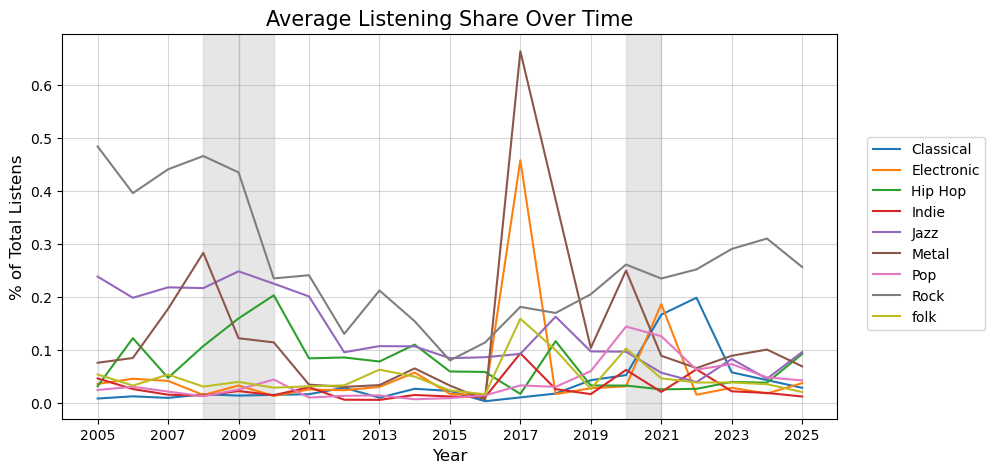

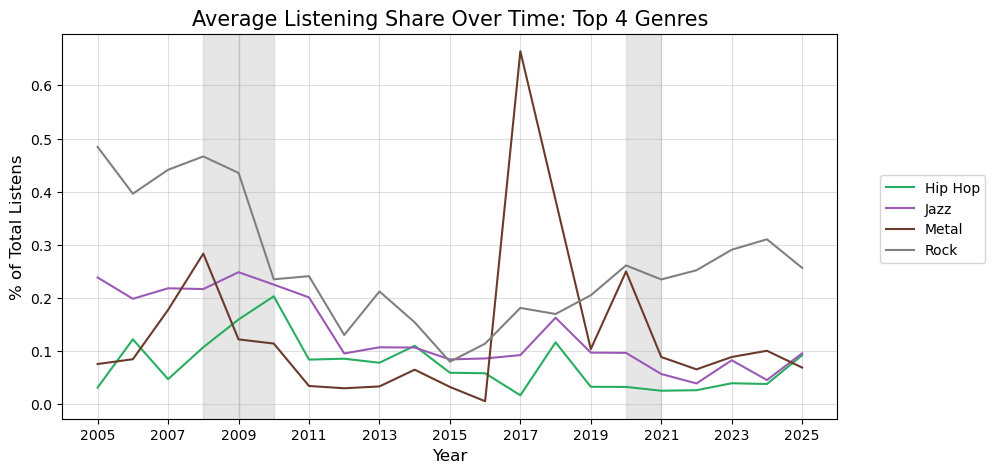

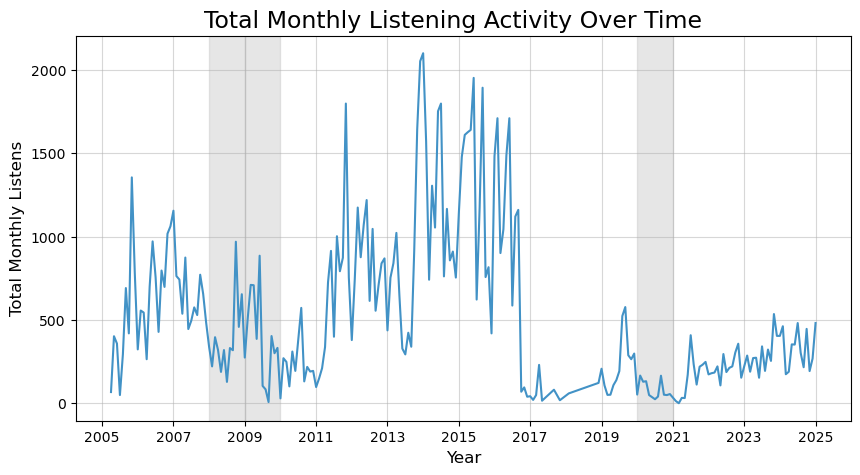

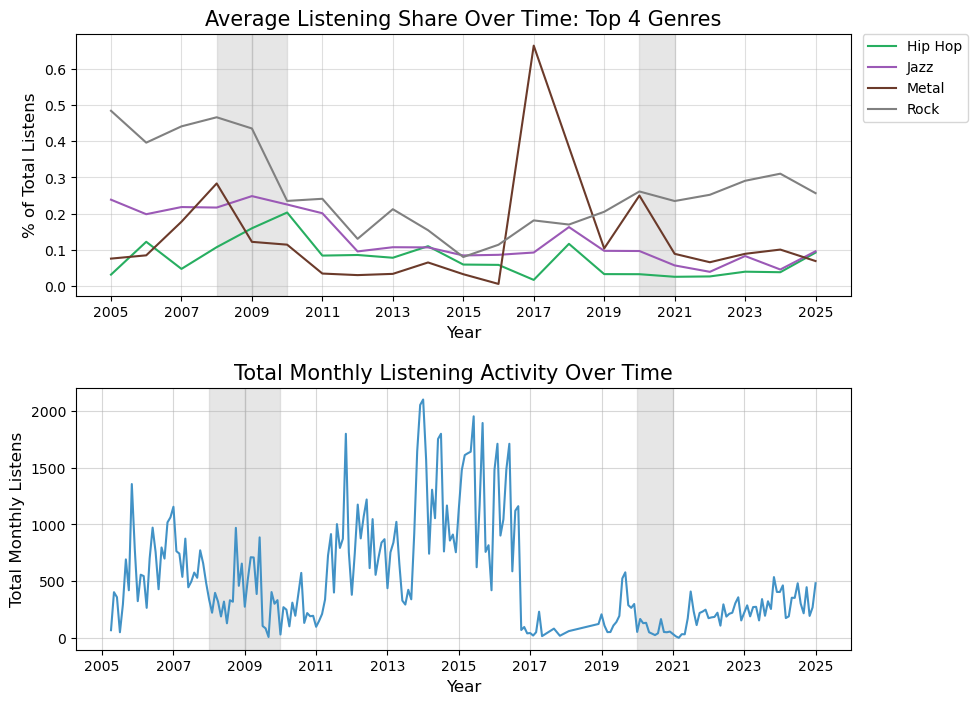

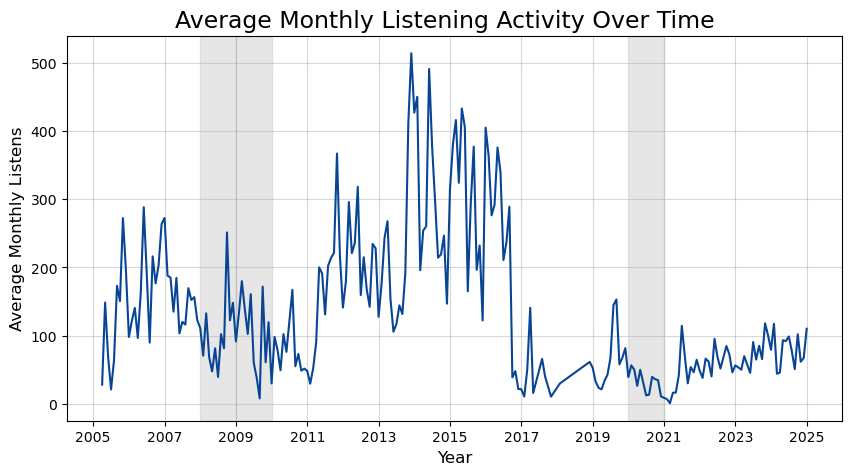

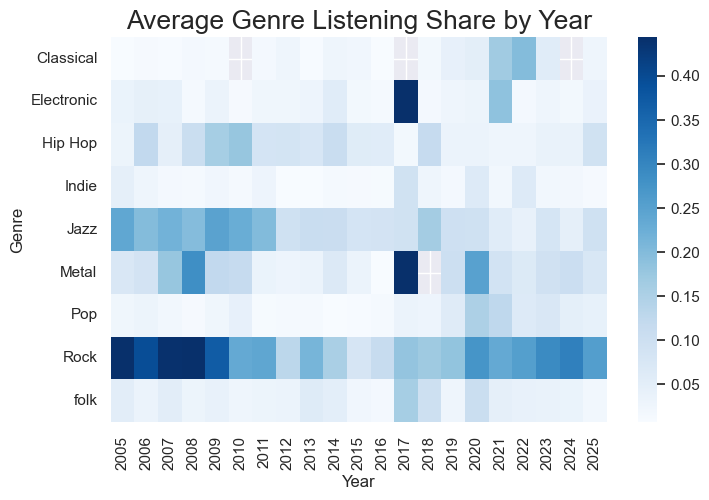

In [19]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
#_________________________________________________________________________________________________________________________________________
#BLOCK 2.1 - Load Up Graph Data
graph_path= '/Users/alex/Documents/Pace/Classes/Junior/Spring/Data Analytics/Final Project/final-project-atuosto1/'
graph_data=pd.read_csv(f'{graph_path}/RealFinalDF.csv')
linegraph=graph_data[['Genre','Play Share','Year']]
#gets all of my data loaded up and sorted how I want it 
#_________________________________________________________________________________________________________________________________________
#BLOCK 2.2 - Make Graph 1 - Spaghetti Graph

groupedgen=linegraph.groupby(['Genre','Year'],as_index=False)['Play Share'].mean() 
#https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-groupby/
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html#:~:text=pandas.DataFrame.groupby-,DataFrame.,as%20a%20(single)%20key.
#just doing this for rock but I'll eventually make a for loop to get this for every single Genre
# groups my data entries by Genre and Year, False means that these won't become the index so i'm able to pull from them for the graph
groupedgen=groupedgen[groupedgen['Genre']!='other']
#excludes other from my data
plt.figure(figsize=(10,5))
#sets size to 10,5
lp=sns.lineplot(x='Year',y='Play Share',data=groupedgen, hue='Genre')
#actually gets my lineplot set up with an x of year, y of play share, data = my grouped, hue separates lines by genre, palette gets my colors
lp.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) 
# plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
lp.set_xlabel('Year',fontsize=12) 
#sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
lp.set_ylabel('% of Total Listens',fontsize=12) 
#same as above but just for my y label
plt.title('Average Listening Share Over Time', fontsize=15) 
#makes the title with fontsize 17
recession=graph_data[graph_data['REC']==1]['Year'].unique() 
#gets the unique year for each of the recessions
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)
#plots my recession bar if there is a year that has a value ==1 for the recession years
lp.legend(bbox_to_anchor=(1.2, 0.75), loc='upper right')
plt.grid(alpha=0.5)
plt.savefig(graph_path+'/SpaghettiGraph.png', dpi = 500, transparent=False,bbox_inches='tight') 
#https://stackoverflow.com/questions/9651092/my-matplotlib-pyplot-legend-is-being-cut-off, 
# I kept my legend from getting cut off, and bbox_inches keeps that from happening when I export.
plt.show()
#_________________________________________________________________________________________________________________________________________
#BLOCK 2.3 - Make Graph 2 - Less Spaghetti Graph
plt.figure(figsize=(10,5))
#sets the size of the figure I'm using
top4= linegraph[(linegraph['Genre']=='Rock')|(linegraph['Genre']=='Jazz')|
    (linegraph['Genre']=='Metal')|(linegraph['Genre']=='Hip Hop')] 
# get each of the top 4 genres
grouped4=top4.groupby(['Genre','Year'],as_index=False)['Play Share'].mean() 
# groups my top 4 genres by Genre and Year returning values as a mean of each year, False means that these won't become the index so i'm able to pull from them for the graph
colors={'Rock':'#808080','Jazz':'#9B59B6', 'Metal':'#6B3A2A', 'Hip Hop':'#27AE60'} 
# sets my colors into a dictionary seaborn pulls from for the colors, I wanted to keep them the same as the other bad spaghetti graph
lp=sns.lineplot(x='Year',y='Play Share',data=grouped4, hue='Genre', palette=colors)
#actually gets my lineplot set up with an x of year, y of play share, data = my grouped, hue separates lines by genre, palette gets my colors
lp.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) 
# plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
lp.set_xlabel('Year',fontsize=12) 
#sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
lp.set_ylabel('% of Total Listens',fontsize=12) 
#same as above but just for my y label
plt.title('Average Listening Share Over Time: Top 4 Genres', fontsize=15) 
#makes the title with fontsize 17
recession=graph_data[graph_data['REC']==1]['Year'].unique() 
#gets the unique year for each of the recessions
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)
#shared the recession bars again
lp.legend(bbox_to_anchor=(1.2, 0.65), loc='upper right')
#puts my legend in the upper right corner with some fine tune adjustments in the bbox to anchor line
plt.grid(alpha=0.4)
#plots my gridlines somewhat transparent
plt.savefig(graph_path+'/AveListeningShare.png', dpi = 500, transparent=False,bbox_inches='tight')
#Saves the figure to my graph_path location and adds the title, I wanted a white background so i made the transparent condition false
#and I wanted to include the legend in my export
plt.show()
#_________________________________________________________________________________________________________________________________________
#BLOCK 2.4 - Make Graph 3 - Total Monthly listening Activity
plays_monthly = graph_data.groupby(['Year', 'Month'])['Play Share (Number)'].sum().reset_index()#groups the data by year and month returning the sume of the play shares for each month 
clean=plays_monthly.drop_duplicates().reset_index() 
#cleaning my data for this graph
clean=clean[(clean['Year']!=2005)|(clean['Month']!=2)] 
#excludes february of 2005 as there was a huge outlier in this month
clean=clean[clean['Year']<2025] 
#matches the timeline of the data up with the previous graph
plt.figure(figsize=(10,5)) 
#creates the size for the charts
lp=sns.lineplot(x=clean['Year']+clean['Month']/12,y=clean['Play Share (Number)'],color='#4292C6') 
#https://stackoverflow.com/questions/48693316/find-then-convert-the-year-and-month-to-decimal#:~:text=First%20convert%20total%20years%20and,53%20/%2012%20=%204.41%20years.
#Code above just gets the data to be in a decimal point instead of plotting once a year for the total plays, it was an ugly step function before
lp.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) 
# plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
lp.set_xlabel('Year',fontsize=12) 
#sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
lp.set_ylabel('Total Monthly Listens',fontsize=12) 
#same as above but just for my y label
plt.title('Total Monthly Listening Activity Over Time', fontsize=17, horizontalalignment='center', x = 0.487)
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)
    #plots my recession bar if there is a year that has a value ==1 for the recession years
plt.grid(alpha=0.5)
#plots my gridlines somewhat transparent
plt.savefig(graph_path+'/MonthTotal.png', dpi = 500, transparent=False, bbox_inches='tight')
#Saves the figure to my graph_path location and adds the title, I wanted a white background so i made the transparent condition false
#and I wanted to include the legend in my export
plt.show()
#_________________________________________________________________________________________________________________________________________
#BLOCK 2.5 - Make Graph 4 - Stacked Graph

fig, ax = plt.subplots(nrows = 2, ncols = 1,figsize=(10,8))
 #creates the size for the chartsgrouped4=top4.groupby(['Genre','Year'],as_index=False)['Play Share'].mean() 
colors={'Rock':'#808080','Jazz':'#9B59B6', 'Metal':'#6B3A2A', 'Hip Hop':'#27AE60'} 
# sets my colors into a dictionary seaborn pulls from for the colors, I wanted to keep them the same as the other bad spaghetti graph
ax1=sns.lineplot(x='Year',y='Play Share',data=grouped4, hue='Genre', palette=colors,ax=ax[0])
#actually gets my lineplot set up with an x of year, y of play share, data = my grouped, hue separates lines by genre, 
#palette gets my colors, ax makes it so that ax1 is plotting on the 0th subplot https://www.geeksforgeeks.org/python/how-to-create-subplots-in-seaborn/
#https://www.geeksforgeeks.org/python/how-to-create-subplots-in-seaborn/
ax1.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) 
# plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
ax1.set_xlabel('Year',fontsize=12) 
#sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
ax1.set_ylabel('% of Total Listens',fontsize=12) 
#same as above but just for my y label
ax1.set_title('Average Listening Share Over Time: Top 4 Genres', fontsize=15) 
#makes the title with fontsize 17
recession=graph_data[graph_data['REC']==1]['Year'].unique() 
#gets the unique year for each of the recessions
ax1.legend(bbox_to_anchor=(1.16, 1.025), loc='upper right')
ax1.grid(alpha=0.4)
#plots my gridlines somewhat transparent
ax2=sns.lineplot(x=clean['Year']+clean['Month']/12,y=clean['Play Share (Number)'],color='#4292C6', ax=ax[1])
#difference between this and ax1 is that this one has ax=ax[1] this means that we're printing on the 1st subplot
ax2.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) 
# plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
ax2.set_xlabel('Year',fontsize=12) 
#sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
ax2.set_ylabel('Total Monthly Listens',fontsize=12) 
#same as above but just for my y label
ax2.set_title('Total Monthly Listening Activity Over Time', fontsize=15, horizontalalignment='center', x = 0.487)
#sets the title aligned in the center 
ax2.grid(alpha=0.5)
#plots my gridlines somewhat transparent
for year in recession:
     ax1.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)
     ax2.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)
#plots the recession bars for both graphs at the same time
plt.subplots_adjust(hspace=0.35)
#puts a little bit of space vertically in between the two graphs 
plt.savefig(graph_path+'/2Graphs.png', dpi = 500, transparent=False,bbox_inches='tight')
#Saves the figure to my graph_path location and adds the title, I wanted a white background so i made the transparent condition false
#and I wanted to include the legend in my export
#https://stackoverflow.com/questions/9651092/my-matplotlib-pyplot-legend-is-being-cut-off
plt.show()
#_________________________________________________________________________________________________________________________________________
#BLOCK 2.6 - Make Graph 5 - Average Monthtly listening Activity
plays_monthly = graph_data.groupby(['Year', 'Month'])['Total Plays'].mean().reset_index()#groups the data by year and month returning the sume of the play shares for each month 
aveclean=plays_monthly.drop_duplicates().reset_index() #cleaning my data for this graph
aveclean=aveclean[(aveclean['Year']!=2005)|(aveclean['Month']!=2)] #excludes february of 2005 as there was a huge outlier in this month
aveclean=aveclean[aveclean['Year']<2025] #matches the timeline of the data up with the previous graph
plt.figure(figsize=(10,5)) #creates the size for the charts
lp=sns.lineplot(x=aveclean['Year']+aveclean['Month']/12,y=aveclean['Total Plays'],color='#084594') #https://stackoverflow.com/questions/48693316/find-then-convert-the-year-and-month-to-decimal#:~:text=First%20convert%20total%20years%20and,53%20/%2012%20=%204.41%20years.
#stuff above just gets the data to be in a decimal point instead of plotting once a year for the total plays, it was a gross ugly step function before
lp.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) 
# plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
lp.set_xlabel('Year',fontsize=12) 
#sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
lp.set_ylabel('Average Monthly Listens',fontsize=12) 
#same as above but just for my y label
plt.title('Average Monthly Listening Activity Over Time', fontsize=17, horizontalalignment='center', x = 0.487)
#plots title and aligns it in the center of my graphs
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)
plt.grid(alpha=0.5)
#plots gridlines with an alpha of 0.5
plt.savefig(graph_path+'/MeanMonthlyListen.png', dpi = 500, transparent=False, bbox_inches='tight')
#Saves the figure to my graph_path location and adds the title, I wanted a white background so i made the transparent condition false
#and I wanted to include the legend in my export
plt.show()
#_________________________________________________________________________________________________________________________________________
#BLOCK 2.7 - Make Graph 6 - Heatmap (Average Genre Listening Share by Year)
sns.set(font_scale=1)
#sets the font size for the heatmap
plt.figure(figsize=(8,5))
#makes the general blank figure
heatmap=linegraph[linegraph['Genre']!='other'] 
#makes the heatmap data the linegraph data as well
heatmapdata = heatmap[['Year','Genre', 'Play Share']].drop_duplicates() 
#puts all the data we need into one dataframe specific for the heatma[
hm = heatmapdata.pivot_table(index= 'Genre',columns = 'Year',values = 'Play Share',aggfunc='mean')
#I found this out at the links below, since I have 2 category variables this is considered a 3d pivot table
#that means I had to do the pivot table function instead of just pivot like we had in the lecture
#i also had to use the aggfunc which basically means that each of the index values will be the mean for each year for each Genre
#https://seaborn.pydata.org/generated/seaborn.heatmap.html
#https://stackoverflow.com/questions/69968235/pivot-table-in-proper-order-for-the-heatmap
#https://saturncloud.io/blog/pandas-pivot-table-list-of-aggfunc-a-guide/
plt.title('Average Genre Listening Share by Year', fontsize=19)
#plots the title in a font with a size of 19
sns.heatmap(hm, cmap='Blues', robust= True) 
#gets my data, my continuous mapping, and looks at the robust percentiles (98th% and 2nd% true)
plt.savefig(graph_path+'/Heatmap.png', dpi = 500, transparent=False, bbox_inches='tight')
#Saves the figure to my graph_path location and adds the title, I wanted a white background so i made the transparent condition false
#and I wanted to include the legend in my export
plt.show()
#sns.reset_orig() #this resets the seaborn theme because I nearly had a heart attack when I changed the theme and my other graphs changed